In [ ]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA


In [ ]:
df = pd.read_csv("heart (2).csv")

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

# Apply Label Encoding first
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Apply One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)


In [ ]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier()
}

print("Accuracy BEFORE PCA:\n")

results_before = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results_before[name] = acc
    print(f"{name}: {acc:.4f}")


Accuracy BEFORE PCA:

Logistic Regression: 0.8478
SVM: 0.8641
Random Forest: 0.8859


In [ ]:

# Keep 95% variance
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("\nNumber of components after PCA:", pca.n_components_)


Number of components after PCA: 10


In [ ]:
print("\nAccuracy AFTER PCA:\n")

results_after = {}

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    acc = accuracy_score(y_test, y_pred)
    results_after[name] = acc
    print(f"{name}: {acc:.4f}")



Accuracy AFTER PCA:

Logistic Regression: 0.8370
SVM: 0.8804
Random Forest: 0.8478


In [ ]:

print("\n--- Comparison ---")
for model in models.keys():
    print(f"{model}: Before PCA = {results_before[model]:.4f}, After PCA = {results_after[model]:.4f}")


--- Comparison ---
Logistic Regression: Before PCA = 0.8478, After PCA = 0.8370
SVM: Before PCA = 0.8641, After PCA = 0.8804
Random Forest: Before PCA = 0.8859, After PCA = 0.8478


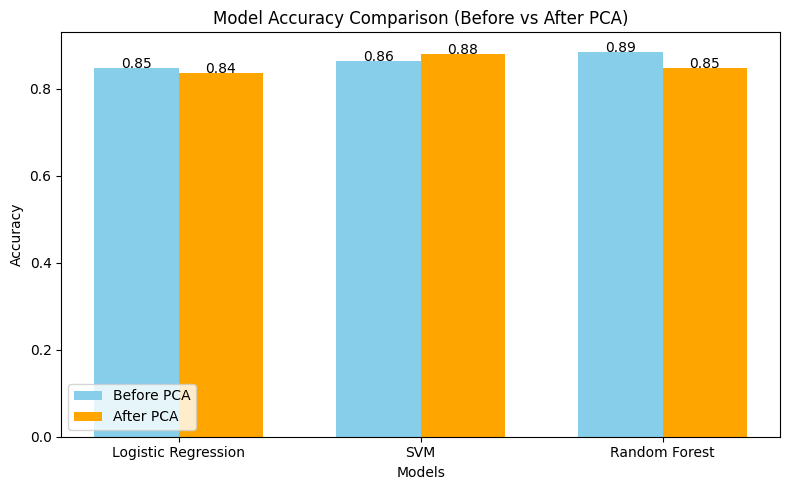

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models_list = list(results_before.keys())

# Accuracy values
before_vals = list(results_before.values())
after_vals = list(results_after.values())

x = np.arange(len(models_list))
width = 0.35

plt.figure(figsize=(8,5))

# Bar plots
plt.bar(x - width/2, before_vals, width, label='Before PCA', color='skyblue')
plt.bar(x + width/2, after_vals, width, label='After PCA', color='orange')

# Labels and title
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison (Before vs After PCA)")
plt.xticks(x, models_list)
plt.legend()

# Show values on top
for i in range(len(models_list)):
    plt.text(x[i] - width/2, before_vals[i], f"{before_vals[i]:.2f}", ha='center')
    plt.text(x[i] + width/2, after_vals[i], f"{after_vals[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()